In [1]:
import hea
import polars as pl


In [2]:
data = pl.read_csv("https://raw.githubusercontent.com/berenslab/rgc_dendrites/refs/heads/master/data/processed/all_roi.csv")

data = hea.tbl(data).rename(
    soma_dist="dendritic_distance_to_soma", 
    rf_size="sRF_asd_upsampled_cntr_size_65",
    offset="cntrs_offset_calibrate_to_rois_65", 
    quality="cntr_quality"
)
data = data.select("exp_date", "recording_id", "roi_id", "type", "soma_dist", "rf_size", "quality", "offset")
data = data.with_columns(
    hea.factor(
        data["type"], 
        labels={"0":"alpha transient", "1":"sustained", "2":"mini alpha", "3":"f-mini"}
    ), 
)
data = data.filter((pl.col("soma_dist") < 200)).filter(pl.col("quality") == 1)


In [3]:
data = data.with_columns(hea.factor(data["exp_date"]))

In [4]:
data

exp_date,recording_id,roi_id,type,soma_dist,rf_size,quality,offset
enum,i64,i64,enum,f64,f64,i64,f64
"""20161028_1""",0,0,"""alpha transient""",0.0,12.442011,1,12.809315
"""20161028_1""",1,1,"""alpha transient""",46.639967,10.099504,1,11.226635
"""20161028_1""",1,2,"""alpha transient""",34.984462,11.055209,1,6.573385
"""20161028_1""",1,3,"""alpha transient""",43.314967,11.048211,1,11.440616
"""20161028_1""",1,4,"""alpha transient""",69.875143,8.860962,1,5.762906
…,…,…,…,…,…,…,…
"""20180216_2""",5,5,"""f-mini""",135.294566,6.779088,1,48.884045
"""20180216_2""",5,6,"""f-mini""",116.090645,6.812224,1,34.875612
"""20180216_2""",5,7,"""f-mini""",131.010081,8.755394,1,44.422172


In [5]:
from hea import gam

In [6]:
m1 = gam('rf_size ~ type + s(soma_dist, by=type, k=50)', data = data)
m1.summary()


Family: gaussian
Link function: identity

Formula: rf_size ~ type + s(soma_dist, by=type, k=50)

Parametric coefficients:
                Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)      10.9384      0.1315   83.167   < 2e-16  ***
typesustained     0.4065      0.3521    1.155     0.248
typemini alpha   -1.3627      0.2562   -5.318  1.23e-07  ***
typef-mini       -4.0205      0.3410  -11.789   < 2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                     edf  Ref.df        F  p-value
s(soma_dist):typealpha transient  11.704  14.565  11.2966  < 2e-16  ***
s(soma_dist):typesustained         4.377   5.526   2.9041  0.01013  *
s(soma_dist):typemini alpha        1.012   1.025   7.4095  0.00620  **
s(soma_dist):typef-mini            1.833   2.307   0.3907  0.70625
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) = 0.203  Deviance explained = 21.6%
GCV = 12.473

In [7]:
m2 = gam('rf_size ~ type + s(soma_dist, by=type, k=50) + s(exp_date, bs="re")', data = data)
m2.summary()


Family: gaussian
Link function: identity

Formula: rf_size ~ type + s(soma_dist, by=type, k=50) + s(exp_date, bs="re")

Parametric coefficients:
                Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)      12.7394      0.9679  13.1616   < 2e-16  ***
typesustained    -1.4720      2.2130  -0.6652   0.50606
typemini alpha   -2.2966      2.0233  -1.1351   0.25656
typef-mini       -5.8777      2.0320  -2.8926   0.00389  **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                     edf  Ref.df        F   p-value
s(soma_dist):typealpha transient  10.628  13.241  21.5841   < 2e-16  ***
s(soma_dist):typesustained         4.821   6.094   2.6343  0.014732  *
s(soma_dist):typemini alpha        1.599   2.015   7.5682  0.000521  ***
s(soma_dist):typef-mini            1.806   2.265   0.5073  0.625214
s(exp_date)                       26.410  26.976  31.5859   < 2e-16  ***
---
Signif. codes: 0 '***' 0.0

In [8]:
hea.AIC(m1, m2)

           df      AIC
m1  26.410232  7105.15
m2  54.107930  6437.74


<Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical Quantiles', ylabel='Std. deviance resid.'>

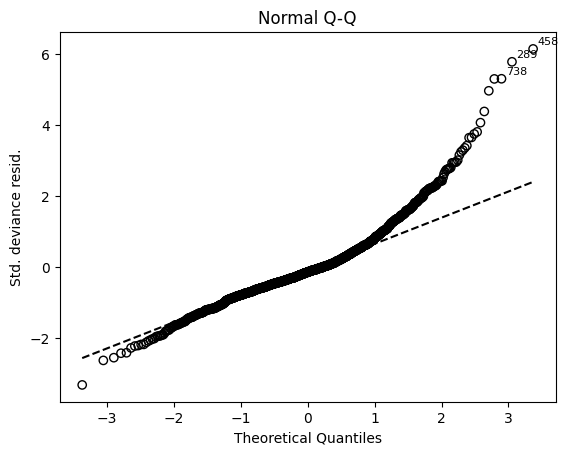

In [9]:
m2.plot_qq()

In [10]:
_ = m2.check()

Method: GCV.Cp   Optimizer: outer newton
full convergence after 7 iterations.
Gradient range [-2.089312e-09,9.741802e-07]
(score 7.527532 & scale 7.247437).
Hessian positive definite, eigenvalue range [0.001670258,0.013248].
Model rank = 231 / 231

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                                     k'    edf  k-index  p-value
s(soma_dist):typealpha transient  49.00  10.63    0.974     0.25
s(soma_dist):typesustained        49.00   4.82    0.974     0.13
s(soma_dist):typemini alpha       49.00   1.60    0.974     0.15
s(soma_dist):typef-mini           49.00   1.81    0.974     0.14
s(exp_date)                       31.00  26.41      NaN      NaN
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


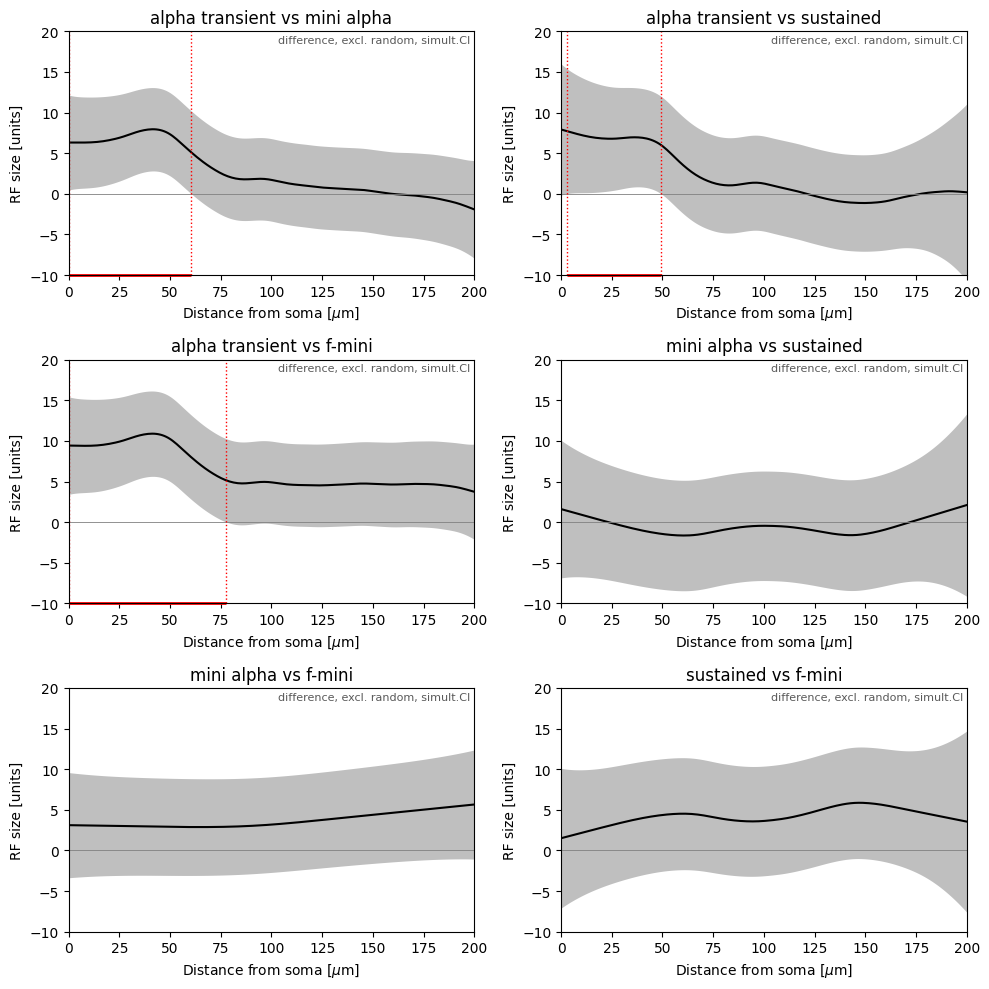

In [11]:
from itertools import combinations
import matplotlib.pyplot as plt

types = ["alpha transient", "mini alpha", "sustained", "f-mini"]

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for ax, (t, d) in zip(axes.ravel(), combinations(types, 2)):
    m2.plot_diff(
        view="soma_dist",
        comp={"type": (t, d)},
        sim_ci=True,
        rm_ranef=True,
        print_summary=False,
        hide_label=False,
        xlab=r"Distance from soma [$\mu$m]",
        ylab="RF size [units]",
        title=f"{t} vs {d}",
        xlim=(0, 200),
        ylim=(-10, 20),
        ax=ax,
    )
fig.tight_layout()
plt.show()